# Moments of the Particle-in-a-Box

In this notebook, we will work with moments, $\langle x^n \rangle$, for the one-dimensional particle-in-a-box.

The moments of the particle-in-a-box are defined as:
$$
m_{k;n} = \langle x^k \rangle = \int_0^a \psi_n^*(x)\, x^k \,\psi_n(x) dx
$$

The property density for the moment operator is thus defined as
$$
m_{k;n}(x) = x^k \left|\psi_n(x)\right|^2
$$

### $n=1$

The average position is expected to be

$$
\langle x \rangle =\tfrac{a}{2}
$$

We can confirm this by explicit integration,

$$
\begin{align}
\langle x \rangle &= \int_0^a \psi_n^*(x)\, x \,\psi_n(x) dx \\
&= \int_0^a \left(\sqrt{\tfrac{2}{a}} \sin\left(\tfrac{n \pi x}{a} \right)\right) x \left(\sqrt{\tfrac{2}{a}}\sin\left(\tfrac{n \pi x}{a} \right)\right) dx \\
&= \tfrac{2}{a} \int_0^a  x \sin^2\left(\tfrac{n \pi x}{a} \right) dx \\
&= \tfrac{2}{a} \left[ \tfrac{x^2}{4} - x \tfrac{\sin \tfrac{2n \pi x}{a}}{\tfrac{4 n \pi}{a}}  
- \tfrac{\cos \tfrac{2n \pi x}{a}}{\tfrac{8 n^2 \pi^2}{a^2}}  
 \right]_0^a \\
 &= \tfrac{2}{a} \left[ \tfrac{a^2}{4} - 0 - 0 \right] \\
 &= \tfrac{a}{2}
\end{align}
$$



### $n=2$
Similarly, we expect that the expectation value of $\langle x^2 \rangle$ will be proportional to $a^2$. We can confirm this by explicit integration,

$$
\begin{align}
\langle x^2 \rangle &= \int_0^a \psi_n^*(x)\, x^2 \,\psi_n(x) dx \\
&= \int_0^a \left(\sqrt{\tfrac{2}{a}} \sin\left(\tfrac{n \pi x}{a} \right)\right) x^2 \left(\sqrt{\tfrac{2}{a}}\sin\left(\tfrac{n \pi x}{a} \right)\right) dx \\
&= \tfrac{2}{a} \int_0^a  x^2 \sin^2\left(\tfrac{n \pi x}{a} \right) dx \\
&= \tfrac{2}{a} \left[ \tfrac{x^3}{6}
 - x^2 \tfrac{\sin \tfrac{2n \pi x}{a}}{\tfrac{4 n \pi}{a}}
 - x \tfrac{\cos \tfrac{2n \pi x}{a}}{\tfrac{4 n^2 \pi^2}{a^2}}
 - \tfrac{\sin \tfrac{2n \pi x}{a}}{\tfrac{8 n^3 \pi^3}{a^3}}
 \right]_0^a \\
 &= \tfrac{2}{a} \left[ \tfrac{a^3}{6} - 0 - \tfrac{a}{{\tfrac{4 n^2 \pi^2}{a^2}}} - 0 \right] \\
  &= \tfrac{2}{a} \left[ \tfrac{a^3}{6} - \tfrac{a^3}{4 n^2 \pi^2} \right] \\
  &= a^2\left[ \tfrac{1}{3} - \tfrac{1}{2 n^2 \pi^2} \right]
\end{align}
$$



### $n \ge 0$
Arbitrary moments can be determined using the [generalized hypergeometric function](https://en.wikipedia.org/wiki/Generalized_hypergeometric_function) ${}_1F_2(a;b_1,b_2;z)$. Specifically, we have
$$
\begin{align}
m_{k,n} &= \frac{2}{a} \int_0^a  x^k \sin^2\left(\tfrac{n \pi x}{a}\right) \,dx \\
&=\frac{a^k}{k+1} \left[1-{}_1F_2\left(\tfrac{k+1}{2};\tfrac{1}{2},\tfrac{k+3}{2};-(n \pi)^2 \right)\right]
\end{align}
$$

### &#x1f469;&#x1f3fd;&#x200d;&#x1f4bb; Assignment: Complete the Below Notebook
Use the above example to calculate $\langle x^n \rangle$, comparing the numerical integration against the explicit formula, and confirming the correctness of the formula using ${}_1F_2$ for the first and second moments. To do this, complete the code blocks indicated by  `### START YOUR CODE HERE`  and  `### END YOUR CODE HERE` .

The detailed steps you'll follow are:
1. Complete the `compute_wavefunction` function by coding the expression for calculating the wavefunction. Don't forget the normalization constant. Take into account that x values less than zero or greater than $a$. Support the case where $x$ is simply a real number (a `float`) as well as the case where $x$ is a numpy array (a `numpy.ndarray`).
1. Use the `compute_wavefunction` function to complete the `compute_probability` function.
1. Fill the gaps in `compute_moment_density` function; this is easiest if you use  the `compute_probability` function.
1. Complete the functions `compute_moment_numerical` to compute the moment numerically by using the [`quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) function for numerical integration.
1. The remaining functions compare you results with the analytical results. Play with different values of $n$, $k$, and $a$.
1. Upload your notebook and confirm its correctness. The marking scheme is provided at the end of this document.

In [ ]:
import numpy as np
from mpmath import hyp1f2
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Define a function for the wavefunction
def compute_wavefunction(x, n, a):
    """Compute 1-dimensional particle-in-a-box wave-function value(s).

    Parameters
    ----------
    x: float or np.ndarray
        Position of the particle.
    n: int
        Quantum number value.
    a: float
        Length of the box.
    """
    # check argument n=1,2,3,....
    if not (isinstance(n, int) and n > 0):
        raise ValueError("The principle quantum number, n, should be a positive integer.")
    # check argument a > 0
    if a <= 0.0:
        raise ValueError("The length of the box, a, should be positive.")
    # check type for the position variable x
    if not (isinstance(x, float) or hasattr(x, "__iter__")):
        raise ValueError("The position of the particle, x, should be a float or an array.")

    # compute wavefunction

    ### START YOUR CODE HERE
    wavefunction=np.sqrt(2/a)*np.sin(np.pi*n*x/a)
    ### END YOUR CODE HERE

    # set the wavefunction values outside the box equal to zero

    ### START YOUR CODE HERE

    if hasattr(x, "__iter__"):
        wavefunction[x > a] = 0.0
        wavefunction[x < 0] = 0.0
    else:
        if x < 0.0 or x > a:
            wavefunction = 0.0

    ### END YOUR CODE HERE

    return wavefunction

# Define a function for the wavefunction squared
def compute_probability(x, n, a):
    """Compute 1-dimensional particle-in-a-box probablity value(s).

    See `compute_wavefunction` parameters.
    """
    ### START YOUR CODE HERE
    probability = compute_wavefunction(x, n, a)**2
    ### END YOUR CODE HERE
    return probability

def compute_moment_density(x, n, a, power):
    """Compute the property density for the x^power moment of the 1-dimensional particle-in-a-box.
       This is the integrand for computing the moment.
    See `compute_wavefunction` parameters.
    """
    ### START YOUR CODE HERE

    return compute_probability(x, n, a)*x**power
    ### END YOUR CODE HERE

#Compute <x^power>, the expectation value of x^power, using numerical integration.
def compute_moment_numerical(n, a, power):
    """Compute the moment x^power for the n-th state of the box of length a, numerically.
    Compute the average value by numerical integration
    """

    ### START YOUR CODE HERE
    def integrand(x):
        return compute_moment_density(x, n, a, power)
    moment, error = quad(integrand, 0, a)
    ### END YOUR CODE HERE

    return moment

#Compute <x^power>, the expectation value of x^power, using the analytical formula.
def compute_moment_analytical(n, a, power):
    """Compute the moment x^power for the n-th state of the box of length a, analytically.
    Compute the average value by the analytical expression using the 1F2
    generalized hypergeometric function
    """

    moment = a**power/(power+1) * (1 - hyp1f2((power+1)/2,1/2,(power+3)/2,-(n*np.pi)**2))

    return float(moment)


#This next bit of code just prints out the values of the first few moments:
def check_moments(n, a):
    """Compute the first 4 moments for the n-th state of the box of length a.
    Both numerical and analytical formulas are evaluated. For the first two
    moments, the explicit analytical formula is used, in addition to the one
    using the generalized hypergeometric function.
    """

    #compute the moments through fourth order numerically (nmoment_1...nmoment_4)
    nmoment_1 = compute_moment_numerical(n, a, 1)
    nmoment_2 = compute_moment_numerical(n, a, 2)
    nmoment_3 = compute_moment_numerical(n, a, 3)
    nmoment_4 = compute_moment_numerical(n, a, 4)

    #compute the moments through fourth order analytically (mmoment_1,...,mmoment_4)
    mmoment_1 = compute_moment_analytical(n, a, 1)
    mmoment_2 = compute_moment_analytical(n, a, 2)
    mmoment_3 = compute_moment_analytical(n, a, 3)
    mmoment_4 = compute_moment_analytical(n, a, 4)

    #check the computed values of the moments against the analytic formula and the explicit
    #formulas for the first and second moments.
    print(f"<r> numerical   = {nmoment_1:.5f}")
    print(f"<r> analytic    = {mmoment_1:.5f}")
    print(f"<r> explicit    = {a/2:.5f}")
    print(f"<r^2> numerical = {nmoment_2:.5f}")
    print(f"<r^2> analytic  = {mmoment_2:.5f}")
    print(f"<r^2> explicit  = {a**2*(1/3 - 1./(2*n**2*np.pi**2)):.5f}")
    print(f"<r^3> numerical = {nmoment_3:.5f}")
    print(f"<r^3> analytic  = {mmoment_3:.5f}")
    print(f"<r^4> numerical = {nmoment_4:.5f}")
    print(f"<r^4> analytic  = {mmoment_4:.5f}")


#Principle quantum number:
n = 1

#Box length:
a = 1

check_moments(a, n)

<r> numerical   = 0.50000
<r> analytic    = 0.50000
<r> explicit    = 0.50000
<r^2> numerical = 0.28267
<r^2> analytic  = 0.28267
<r^2> explicit  = 0.28267
<r^3> numerical = 0.17401
<r^3> analytic  = 0.17401
<r^4> numerical = 0.11408
<r^4> analytic  = 0.11408


We can also compare these results to the results we know for large powers of $x$ and high principle quantum numbers,
$$
m_{k,n\rightarrow \infty} = \frac{a^k}{k+1}
$$
$$
m_{k\rightarrow \infty,n} =\frac{(2 n \pi)^2 a^{k}}{(k+1)(k+2)(k+3)}
$$

In [ ]:
#Test asymptotic results for the 5-th moment of the 500th state:
nbig = 500
print(f"<r^5> analytic   = {compute_moment_analytical(nbig, a, 5)}")
print(f"<r^5> asymptotic = {a**5/(5+1)}")

#Test asymptotic results for the 500th moment of the 5th state
kbig = 500
print(f"<r^kbig> analytic   = {compute_moment_analytical(5, a, kbig)}")
print(f"<r^kbig> asymptotic = {(2*5*np.pi)**2*a**kbig/((kbig+1)*(kbig+2)*(kbig+3))}")


<r^5> analytic   = 0.16666616006136448
<r^5> asymptotic = 0.16666666666666666
<r^kbig> analytic   = 7.77158220645964e-06
<r^kbig> asymptotic = 7.80171923986404e-06


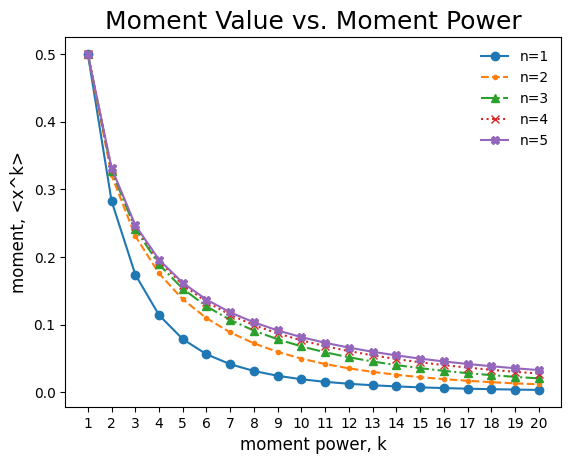

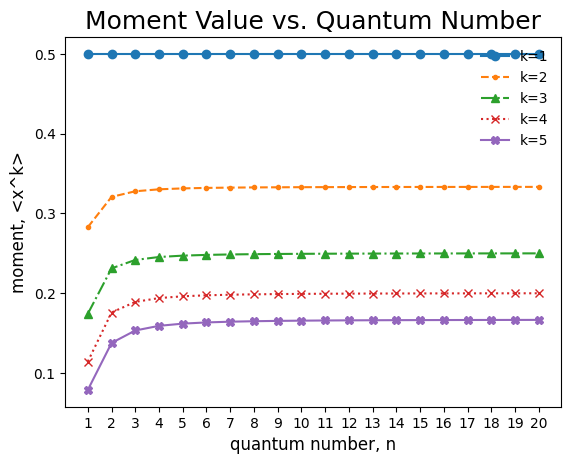

In [ ]:
# Plot moments vs. power for box length a
a = 1

x_values = range(1, 21, 1)
markers = ["o", ".", "^", "x", "X"]
lines = ["-", "--", "-.", "dotted", "-"]

for i, n in enumerate(range(1, 6)):
    y_values = [compute_moment_analytical(n, a, power) for power in x_values]
    plt.plot(x_values, y_values, marker=markers[i], linestyle=lines[i], label=f"n={n}")

plt.xlabel("moment power, k", fontsize=12)
plt.ylabel("moment, <x^k>", fontsize=12)
plt.title("Moment Value vs. Moment Power", fontsize=18)
plt.xticks(x_values)
plt.legend(frameon=False)
plt.show()

# Plot moments vs. quantum number for box length a
a = 1

x_values = range(1, 21, 1)
markers = ["o", ".", "^", "x", "X"]
lines = ["-", "--", "-.", "dotted", "-"]

for i, power in enumerate(range(1, 6)):
    y_values = [compute_moment_analytical(n, a, power) for n in x_values]
    plt.plot(x_values, y_values, marker=markers[i], linestyle=lines[i], label=f"k={power}")

plt.xlabel("quantum number, n", fontsize=12)
plt.ylabel("moment, <x^k>", fontsize=12)
plt.title("Moment Value vs. Quantum Number", fontsize=18)
plt.xticks(x_values)
plt.legend(frameon=False)
plt.show()

## &#x2696;&#xfe0f; Marking Scheme
&#x2611;&#xfe0f; Successful completion of the notebook, together with the ability to discuss your strategy, earns an **S**.

&#x1f4b0; For an **S+**, discuss trends in how the moments change with respect to principle quantum number $n$, and also how the moments change as the power, $k$, increases. You can add this discussion as a Markdown cell at the end of this notebook.

## Discussion: Trends in Moments

### Trends with Quantum Number n

From the plots, we observe how moments change with quantum number n for fixed power k:

1. **First moment** (⟨x⟩): the blue line (k = 1) is perfectly flat at 0.5, meaning that the average position is the same for all quantum states. This is the mean position of our particle.

2. **Higher moments** (k ≥ 2): at high quantum numbers, the wavefunction comprises many tiny oscillations -> averages out to look almost uniform.This is the mean of squared positions of our particles. As a result, moment values Converge to classical physics.

3. **Low n states**: few oscillations -> probability density is clumpy. Non-uniform density -> highly variable moment value (distinct quantum behavior).

higher n means more spatial uncertainty. The particle's position is more spread out and less quantum-localized. Similarly, a classical bouncing particle spends equal time everywhere in the box, so its position is a uniform distribution between [0,a].

### Trends with Power k

For fixed n, as power k increases:
$$
\begin{align}
m_{k,n}&=\frac{a^k}{k+1}...
\end{align}
$$
1. **Monotonic growth**: Moments decrease with k, as expected when raising fractional positions to higher powers. Smaller position values outweigh greater position values as per the function above which utilizes generalized hypergeometric function (...)